In [1]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
from src.index import load_index
from models.embedder import embed_image, embed_text
from src.search import search 
import pandas as pd
from PIL import Image
import os


c:\Users\HP\Desktop\image-search\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
print(os.listdir("data"))

['cifar10', 'embeddings.npy', 'index.faiss', 'index_hnsw.faiss', 'intel', 'metadata.csv', 'metadata_hnsw.csv']


In [3]:
results=search("mountains",k=5)
for r in results:
    print(r)    

[INFO] Loaded index with 3000 vectors
{'index': 1815, 'score': 0.29147908091545105, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\22797.jpg'}
{'index': 1589, 'score': 0.28936126828193665, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\21118.jpg'}
{'index': 1892, 'score': 0.2878202795982361, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\23428.jpg'}
{'index': 1957, 'score': 0.28717395663261414, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\24075.jpg'}
{'index': 1580, 'score': 0.2856333553791046, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\21040.jpg'}


In [4]:
results=search("snow covered mountain peak",k=5)
for r in results:
    print(r)    

[INFO] Loaded index with 3000 vectors
{'index': 1254, 'score': 0.31214475631713867, 'class_name': 'glacier', 'image_path': 'data/intel/seg_test\\glacier\\22800.jpg'}
{'index': 1671, 'score': 0.31087568402290344, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\21781.jpg'}
{'index': 1219, 'score': 0.31042635440826416, 'class_name': 'glacier', 'image_path': 'data/intel/seg_test\\glacier\\22520.jpg'}
{'index': 1610, 'score': 0.3085471987724304, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\21320.jpg'}
{'index': 1543, 'score': 0.30580151081085205, 'class_name': 'mountain', 'image_path': 'data/intel/seg_test\\mountain\\20732.jpg'}


In [5]:
def show_results(query, results):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, len(results)+1, 1)
    if isinstance(query, str) and os.path.exists(query):
        plt.imshow(Image.open(query))
        plt.title("Query Image")
    else:
        plt.text(0.5, 0.5, str(query), ha='center', va='center')
        plt.title("Query Text")
    plt.axis('off')

    for i, r in enumerate(results):
        plt.subplot(1, len(results)+1, i+2)
        plt.imshow(Image.open(r["image_path"]))
        plt.title(f"{r['class_name']}\n{r['distance']:.2f}")
        plt.axis('off')

    plt.show()

In [6]:
def search(query, k=5, index_type="flat"):
    index = load_index(f"data/index_{index_type}.faiss")
    metadata = pd.read_csv(f"data/metadata_{index_type}.csv")

    if hasattr(index, "hnsw"):
        index.hnsw.efSearch = 64

    if isinstance(query, str):
        vector = embed_text(query)
    else:
        vector = embed_image(query)

    vector = vector.reshape(1, -1).astype("float32")
    distances, indices = index.search(vector, k)

    results = []
    for idx, dist in zip(indices[0], distances[0]):
        row = metadata.iloc[idx]
        results.append({
            "index": int(idx),
            "distance": float(dist),
            "class_name": row.get("class_name", ""),
            "image_path": row.get("image_path", "")
        })

    return results  

[INFO] Loaded index with 3000 vectors


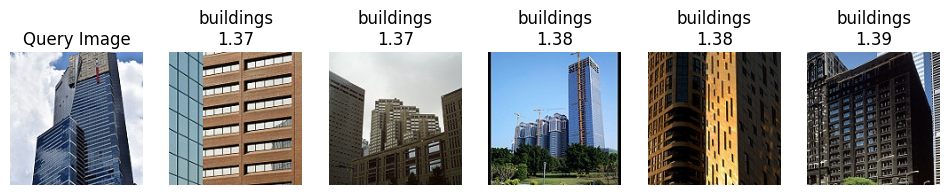

1.374043583869934
1.3747419118881226
1.3838410377502441
1.3849918842315674
1.3899437189102173


In [7]:
results = search("data/intel/seg_test/buildings/20057.jpg", index_type="hnsw")
show_results("data/intel/seg_test/buildings/20057.jpg", results)
for r in results:
    print(r["distance"])